## Example colocating EarthCARE and lightning cluster

In [1]:
!pip install s3fs scikit-learn stratify

In [2]:
# Imports and storage configuration
import geopandas as gpd
import pandas as pd
import pystac
from pystac_client import Client
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from IPython.display import Image, display
import pathlib
import os
from pathlib import Path
import requests
import aiohttp

# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

### Process:
 - Find lightning clusters for each file from `EC_lightning_clusters.parquet`
 - Get lightning counts along-track from `EC_track_lightning_LI.parquet`
 - Find 256 points along CPR track around peak
 - Search for EarthCARE data product and read into `xarray.Dataset`
 - Colocate EarthCARE points and regrid to standard height levels

## Find lightning cluster

In [3]:
selected_file = 'EC_lightning_clusters.parquet'
earthcare_id = "01101E"

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id), ('source', "==", "LI")],
)
gdf

,unique_id,earthcare_id,source,parent_cluster_id,cluster_id,surface_type,peak_datetime,peak_lat,peak_lon,peak_lightning,...,cluster_area_km2,cluster_mean_lat,cluster_mean_lon,cluster_dist_km,first_lightning_min,last_lightning_min,duration_min,travel_km,missing_peak_minutes,geometry
0,01101E_LI_0,01101E,LI,5,0,land,2024-08-07 17:49:47.641487616+00:00,-19.374586,-59.341534,1,...,150.0,-19.415436,-59.256775,9.583754,-23,10,34,50.396728,0.0,POINT (-59.34153 -19.37459)


In [4]:
selected_file_track = 'EC_track_lightning_LI.parquet'
earthcare_id = "01101E"

gdf_track = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file_track}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id)],
)
gdf_track

,cluster_id,lightning_count_2p5,lightning_count_5,time,land_flag,earthcare_id,source,geometry
0,0,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
1,1,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
2,2,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
3,0,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
4,1,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
...,...,...,...,...,...,...,...,...
14695,1,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14696,2,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14697,0,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)
14698,1,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)


## Find total lightning counts (along track) for all clusters:

In [5]:
gdf_track.time.groupby(gdf_track.geometry).first()

geometry
POINT (-60.00686 -22.62717)   2024-08-07 17:50:38.060116608
POINT (-60.00499 -22.61821)   2024-08-07 17:50:37.921192704
POINT (-60.00313 -22.60925)   2024-08-07 17:50:37.782268672
POINT (-60.00127 -22.60029)   2024-08-07 17:50:37.643344768
POINT (-59.9994 -22.59134)    2024-08-07 17:50:37.504420608
                                           ...             
POINT (-51.27595 22.59005)    2024-08-07 17:38:58.766475264
POINT (-51.27411 22.59892)    2024-08-07 17:38:58.629081216
POINT (-51.27227 22.60779)    2024-08-07 17:38:58.491687296
POINT (-51.27042 22.61666)    2024-08-07 17:38:58.354293248
POINT (-51.26858 22.62553)    2024-08-07 17:38:58.216899200
Name: time, Length: 4900, dtype: datetime64[ns]

In [6]:
total_lightning_counts = gdf_track[["lightning_count_2p5", "lightning_count_5"]].groupby(gdf_track.geometry).sum()
total_lightning_counts["time"] = gdf_track.time.groupby(gdf_track.geometry).first()
total_lightning_counts = gpd.GeoDataFrame(total_lightning_counts.reset_index())

In [7]:
total_lightning_counts

,geometry,lightning_count_2p5,lightning_count_5,time
0,POINT (-60.00686 -22.62717),0,0,2024-08-07 17:50:38.060116608
1,POINT (-60.00499 -22.61821),0,0,2024-08-07 17:50:37.921192704
2,POINT (-60.00313 -22.60925),0,0,2024-08-07 17:50:37.782268672
3,POINT (-60.00127 -22.60029),0,0,2024-08-07 17:50:37.643344768
4,POINT (-59.9994 -22.59134),0,0,2024-08-07 17:50:37.504420608
...,...,...,...,...
4895,POINT (-51.27595 22.59005),0,0,2024-08-07 17:38:58.766475264
4896,POINT (-51.27411 22.59892),0,0,2024-08-07 17:38:58.629081216
4897,POINT (-51.27227 22.60779),0,0,2024-08-07 17:38:58.491687296
4898,POINT (-51.27042 22.61666),0,0,2024-08-07 17:38:58.354293248


<Axes: >

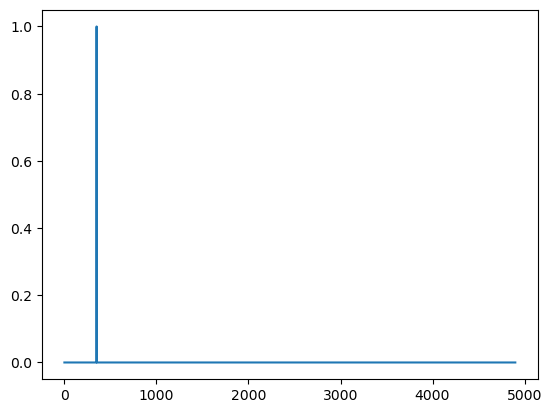

In [8]:
total_lightning_counts.lightning_count_2p5.plot()

In [9]:
type(gdf.geometry[0])

shapely.geometry.point.Point

Find nearest point to cluster centre:

In [10]:
nearest_point = gpd.GeoSeries.distance(total_lightning_counts, gdf.geometry[0]).argmin()
nearest_point

/tmp/ipykernel_3334/2032463108.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest_point = gpd.GeoSeries.distance(total_lightning_counts, gdf.geometry[0]).argmin()


np.int64(349)

In [11]:
lightning_patch = total_lightning_counts.loc[nearest_point-128:nearest_point+127]

In [12]:
lightning_patch

,geometry,lightning_count_2p5,lightning_count_5,time
221,POINT (-59.54305 -20.36944),0,0,2024-08-07 17:50:03.058133632
222,POINT (-59.54708 -20.38922),0,0,2024-08-07 17:50:03.364697728
223,POINT (-59.5489 -20.39816),0,0,2024-08-07 17:50:03.503387648
224,POINT (-59.55072 -20.40711),0,0,2024-08-07 17:50:03.642077696
225,POINT (-59.55255 -20.41606),0,0,2024-08-07 17:50:03.780767744
...,...,...,...,...
472,POINT (-59.12142 -18.27713),0,0,2024-08-07 17:49:30.640949760
473,POINT (-59.11963 -18.26819),0,0,2024-08-07 17:49:30.502457600
474,POINT (-59.05165 -17.9275),0,0,2024-08-07 17:49:25.225389696
475,POINT (-59.05343 -17.93644),0,0,2024-08-07 17:49:25.363845888


In [13]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)


In [14]:
from scripts.load_earthcare import process_earthcare_patch

In [15]:
process_earthcare_patch(
    lightning_patch, 
    "01101E_LI_0", 
    product_vars = dict(
        ACM_CAP_2B=[
            "ice_water_content", 
            "ice_mass_flux", 
            "ice_effective_radius", 
            "ice_median_volume_diameter", 
            "ice_riming_factor", 
            "rain_rate", 
            "rain_water_content", 
            "rain_median_volume_diameter", 
            "liquid_water_content", 
            "liquid_number_concentration", 
            "liquid_effective_radius", 
            "aerosol_number_concentration", 
            "aerosol_mass_content", 
        ],
        CPR_CD__2A=[
            "doppler_velocity_best_estimate", 
            "sedimentation_velocity_best_estimate", 
            "spectrum_width_integrated", 
        ], 
        CPR_FMR_2A=[
            "reflectivity_no_attenuation_correction", 
            "reflectivity_corrected", 
            "multiple_scattering_status", 
        ], 
        CPR_TC__2A=[
            "simplified_convective_classification",
        ]
    ),
)

In [16]:
xr.open_dataset("earthcare_01101E_LI_0.h5", engine="h5netcdf")

<xarray.Dataset> Size: 5MB
Dimensions:                                 (along_track: 256, height: 200)
Coordinates:
  * along_track                             (along_track) int64 2kB 221 ... 476
    time                                    (along_track) datetime64[ns] 2kB ...
    latitude                                (along_track) float64 2kB ...
    longitude                               (along_track) float64 2kB ...
  * height                                  (height) float64 2kB 50.0 ... 1.9...
Data variables: (12/22)
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 205kB ...
    ice_mass_flux                           (along_track, height) float32 205kB ...
    ice_effective_radius                    (along_track, height) float32 205kB ...
    ice_median_volume_diameter              (along_track, height) float32 205kB ...
    ...                                      ...
    sedimentation_velocity_best_estimate    (along_track, height) float32 205kB ...
    spectrum_width_integrated               (along_track, height) float32 205kB ...
    reflectivity_no_attenuation_correction  (along_track, height) float32 205kB ...
    reflectivity_corrected                  (along_track, height) float32 205kB ...
    multiple_scattering_status              (along_track, height) float64 410kB ...
    simplified_convective_classification    (along_track, height) float64 410kB ...